# Complete-Set Lock v1 Historical Tail Diagnostic

## Technical summary

The frozen immediate complete-set lock is **rejected as a research candidate**. Across 14 exact 8-hour folds it improved the unchanged baseline by `$4.43718`, but remained negative at `-$8.15098`. Its high Wilson bound hides severe payoff compression: 47 terminal winners were locked early, the payoff ratio fell to `0.055696`, profit factor stayed below one, and both chronological halves were negative.

This notebook recomputes the result from the sealed raw reports. The history earns no promotion credit and no v1 parameter or neighbor is searched.

In [1]:
import json
import math
import tarfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

ROOT = Path.cwd()
assert (ROOT / 'deploy').is_dir(), 'execute from the repository root'
EVIDENCE = ROOT / 'deploy/promotions/evidence/strategy_registry'
ARCHIVE = EVIDENCE / '20260718_complete_set_lock_v1_historical_tail_raw_reports.tar.gz'
DIAGNOSTIC = EVIDENCE / '20260718_complete_set_lock_v1_historical_tail_diagnostic.json'
BASELINE_HASH = 'a5d67641653ae85a853aab531060a240eade257e32fd5bf0e46392c7934302d5'
CANDIDATE_HASH = 'c25aa94ad592b6274150e48be7765ace8fa3beba85595e48225906ca01c01363'
diagnostic = json.loads(DIAGNOSTIC.read_text())

In [2]:
def read_member(archive, name):
    handle = archive.extractfile(name)
    assert handle is not None, name
    return json.load(handle)

folds = []
all_trades = {'baseline': [], 'candidate': []}
winning_tokens = {}
with tarfile.open(ARCHIVE, 'r:gz') as archive:
    assert len(archive.getmembers()) == 42
    for fold in range(29, 43):
        prefix = f'fold_{fold:03d}'
        hydrate = read_member(archive, f'{prefix}/hydrate.json')
        sweep = read_member(archive, f'{prefix}/sweep.json')
        report = read_member(archive, f'{prefix}/trades.json')
        assert hydrate['markets'] == 96
        assert sweep['data_manifest']['complete'] is True
        assert all(source['complete'] and source['row_count'] > 0 for source in sweep['data_manifest']['sources'])
        assert len(sweep['market_catalog']['markets']) == 96
        variants = {row['strategy']['params_hash']: row for row in sweep['variants']}
        assert set(variants) == {BASELINE_HASH, CANDIDATE_HASH}
        market_map = sweep['market_catalog']['markets']
        fold_row = {'fold': fold}
        for label, variant_hash, report_index in [
            ('baseline', BASELINE_HASH, 0), ('candidate', CANDIDATE_HASH, 1)
        ]:
            sweep_variant = variants[variant_hash]
            report_variant = report['variants'][report_index]
            trades = report_variant['trades']
            summary = report_variant['summary']
            assert report_variant['strategy_params'] == sweep_variant['strategy_params']
            assert not report_variant['unresolved_fills'] and summary['unresolved_fills'] == 0
            assert not sweep_variant['breaker_tripped']
            assert summary['trades'] == len(trades) == sweep_variant['trades']
            pnl = sum(trade['pnl_after_fee'] for trade in trades)
            fees = sum(
                trade['fill']['fee'] + (trade.get('exit', {}).get('fill', {}).get('fee', 0.0))
                for trade in trades
            )
            assert math.isclose(pnl, summary['total_pnl'], abs_tol=1e-8)
            assert math.isclose(fees, summary['total_fees'], abs_tol=1e-8)
            fold_row[f'{label}_pnl'] = pnl
            all_trades[label].extend((fold, trade) for trade in trades)
            for trade in trades:
                cid = trade['fill']['order']['condition_id']
                winning_tokens[(fold, cid)] = market_map[cid][f"{trade['actual_direction']}_token_id"]
        folds.append(fold_row)

quality = {
    'archive_members': 42,
    'folds': len(folds),
    'markets_per_fold': 96,
    'unresolved_fills': 0,
    'breaker_trips': 0,
    'status': 'PASS',
}
quality

{'archive_members': 42,
 'folds': 14,
 'markets_per_fold': 96,
 'unresolved_fills': 0,
 'breaker_trips': 0,
 'status': 'PASS'}

In [3]:
def wilson_lower(wins, total, z=1.959963984540054):
    p = wins / total
    denominator = 1 + z*z/total
    centre = p + z*z/(2*total)
    margin = z * math.sqrt((p*(1-p) + z*z/(4*total))/total)
    return (centre - margin) / denominator

def aggregate(label):
    trades = [trade for _, trade in all_trades[label]]
    pnls = [trade['pnl_after_fee'] for trade in trades]
    fold_pnls = [fold[f'{label}_pnl'] for fold in folds]
    wins = sum(trade['won'] for trade in trades)
    gross_profit = sum(value for value in pnls if value > 0)
    gross_loss = -sum(value for value in pnls if value < 0)
    avg_win = gross_profit / sum(value > 0 for value in pnls)
    avg_loss = gross_loss / sum(value < 0 for value in pnls)
    tail_count = math.ceil(0.20 * len(fold_pnls))
    bursts = [sum(value < 0 for value in fold_pnls[i:i+5]) for i in range(len(fold_pnls)-4)]
    return {
        'trades': len(trades), 'wins': wins, 'losses': len(trades)-wins,
        'total_pnl': sum(pnls), 'gross_profit': gross_profit, 'gross_loss': gross_loss,
        'profit_factor': gross_profit/gross_loss, 'payoff_ratio': avg_win/avg_loss,
        'wilson_95_lower': wilson_lower(wins, len(trades)),
        'profitable_folds': sum(value > 0 for value in fold_pnls),
        'tail_cvar': sum(sorted(fold_pnls)[:tail_count])/tail_count,
        'max_loss_burst': max(bursts),
        'first_half_pnl': sum(fold_pnls[:7]), 'second_half_pnl': sum(fold_pnls[7:]),
    }

aggregate_result = {'baseline': aggregate('baseline'), 'candidate': aggregate('candidate')}
aggregate_result

{'baseline': {'trades': 43,
  'wins': 33,
  'losses': 10,
  'total_pnl': -12.588160000000004,
  'gross_profit': 38.76447,
  'gross_loss': 51.352630000000005,
  'profit_factor': 0.7548682511489674,
  'payoff_ratio': 0.2287479548936265,
  'wilson_95_lower': 0.6225547970219101,
  'profitable_folds': 4,
  'tail_cvar': -5.071293333333334,
  'max_loss_burst': 4,
  'first_half_pnl': -6.692090000000003,
  'second_half_pnl': -5.896070000000002},
 'candidate': {'trades': 66,
  'wins': 61,
  'losses': 5,
  'total_pnl': -8.150980000000002,
  'gross_profit': 17.280849999999997,
  'gross_loss': 25.43183,
  'profit_factor': 0.6794969139067065,
  'payoff_ratio': 0.05569646835300874,
  'wilson_95_lower': 0.8346080497938948,
  'profitable_folds': 9,
  'tail_cvar': -5.04647,
  'max_loss_burst': 3,
  'first_half_pnl': -1.834430000000003,
  'second_half_pnl': -6.31655}}

In [4]:
def signature(trade):
    fill = trade['fill']
    return fill['order']['condition_id'], round(fill['fill_timestamp_s'], 6), fill['order']['token_id']

baseline = {signature(trade): (fold, trade) for fold, trade in all_trades['baseline']}
candidate = {signature(trade): (fold, trade) for fold, trade in all_trades['candidate']}
common = sorted(set(baseline) & set(candidate))
candidate_only = sorted(set(candidate) - set(baseline))
locks = [(fold, trade) for fold, trade in all_trades['candidate'] if trade.get('exit')]

def hold_pnl(fold, trade):
    fill = trade['fill']
    cid = fill['order']['condition_id']
    won = fill['order']['token_id'] == winning_tokens[(fold, cid)]
    return (fill['filled_size'] if won else 0.0) - fill['cost'] - fill['fee']

winner_locks = [(fold, trade) for fold, trade in locks if hold_pnl(fold, trade) > 0]
loser_locks = [(fold, trade) for fold, trade in locks if hold_pnl(fold, trade) < 0]
state_feedback = {
    'common_entries': len(common),
    'baseline_only_entries': len(set(baseline) - set(candidate)),
    'candidate_only_entries': len(candidate_only),
    'common_baseline_pnl': sum(baseline[key][1]['pnl_after_fee'] for key in common),
    'common_candidate_pnl': sum(candidate[key][1]['pnl_after_fee'] for key in common),
    'candidate_only_pnl': sum(candidate[key][1]['pnl_after_fee'] for key in candidate_only),
    'locks': len(locks), 'terminal_winner_locks': len(winner_locks),
    'terminal_loser_locks': len(loser_locks),
    'winner_lock_delta': sum(trade['pnl_after_fee'] - hold_pnl(fold, trade) for fold, trade in winner_locks),
    'loser_lock_delta': sum(trade['pnl_after_fee'] - hold_pnl(fold, trade) for fold, trade in loser_locks),
}
state_feedback['lock_delta'] = state_feedback['winner_lock_delta'] + state_feedback['loser_lock_delta']
state_feedback

{'common_entries': 43,
 'baseline_only_entries': 0,
 'candidate_only_entries': 23,
 'common_baseline_pnl': -12.588160000000004,
 'common_candidate_pnl': -13.953310000000004,
 'candidate_only_pnl': 5.80233,
 'locks': 59,
 'terminal_winner_locks': 47,
 'terminal_loser_locks': 12,
 'winner_lock_delta': -48.91899,
 'loser_lock_delta': 63.63356,
 'lock_delta': 14.714570000000002}

In [5]:
expected = diagnostic['aggregate']
assert math.isclose(aggregate_result['baseline']['total_pnl'], expected['baseline']['total_pnl_usd'], abs_tol=1e-8)
assert math.isclose(aggregate_result['candidate']['total_pnl'], expected['candidate']['total_pnl_usd'], abs_tol=1e-8)
assert aggregate_result['candidate']['trades'] == expected['candidate']['trades']
assert math.isclose(state_feedback['lock_delta'], diagnostic['lock_accounting']['lock_delta_vs_terminal_hold_usd'], abs_tol=1e-8)
assert state_feedback['common_entries'] == diagnostic['state_feedback_decomposition']['common_entries']

verdict = {
    'quality': quality,
    'candidate_pnl_usd': aggregate_result['candidate']['total_pnl'],
    'candidate_minus_baseline_pnl_usd': aggregate_result['candidate']['total_pnl'] - aggregate_result['baseline']['total_pnl'],
    'candidate_profit_factor': aggregate_result['candidate']['profit_factor'],
    'candidate_payoff_ratio': aggregate_result['candidate']['payoff_ratio'],
    'candidate_wilson_95_lower': aggregate_result['candidate']['wilson_95_lower'],
    'candidate_first_half_pnl': aggregate_result['candidate']['first_half_pnl'],
    'candidate_second_half_pnl': aggregate_result['candidate']['second_half_pnl'],
    'decision': 'REJECT_COMPLETE_SET_LOCK_V1',
}
print(json.dumps(verdict, indent=2))

{
  "quality": {
    "archive_members": 42,
    "folds": 14,
    "markets_per_fold": 96,
    "unresolved_fills": 0,
    "breaker_trips": 0,
    "status": "PASS"
  },
  "candidate_pnl_usd": -8.150980000000002,
  "candidate_minus_baseline_pnl_usd": 4.4371800000000015,
  "candidate_profit_factor": 0.6794969139067065,
  "candidate_payoff_ratio": 0.05569646835300874,
  "candidate_wilson_95_lower": 0.8346080497938948,
  "candidate_first_half_pnl": -1.834430000000003,
  "candidate_second_half_pnl": -6.31655,
  "decision": "REJECT_COMPLETE_SET_LOCK_V1"
}


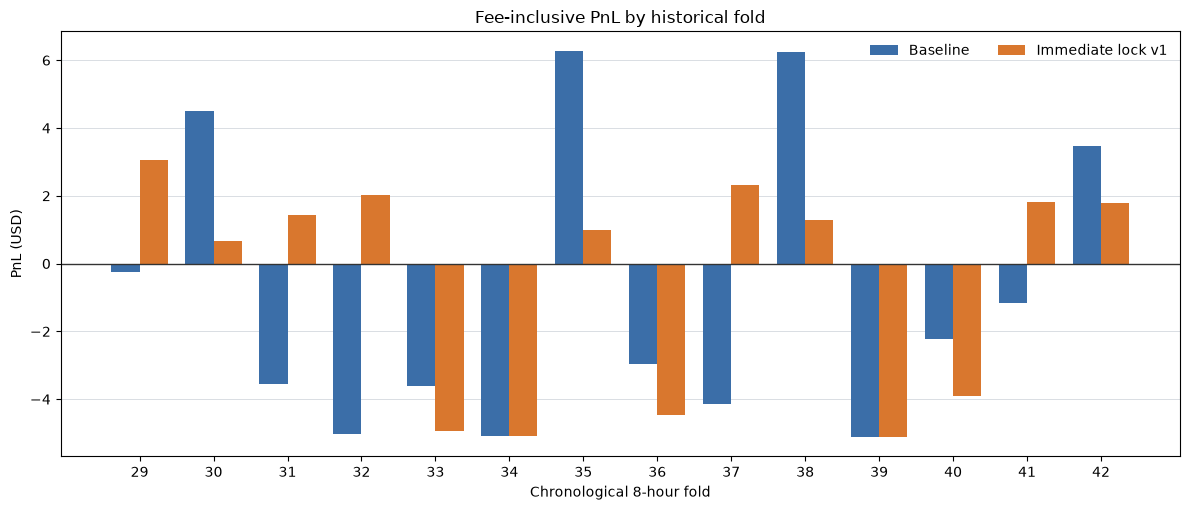

In [6]:
# Chart contract: ordered comparison; grouped bars; 14 independent 8-hour folds;
# blue baseline vs orange candidate plus direct zero-line context.
x = np.arange(len(folds))
width = 0.38
fig, ax = plt.subplots(figsize=(12, 5.2))
ax.bar(x-width/2, [row['baseline_pnl'] for row in folds], width, label='Baseline', color='#3B6EA8')
ax.bar(x+width/2, [row['candidate_pnl'] for row in folds], width, label='Immediate lock v1', color='#D9772E')
ax.axhline(0, color='#333333', linewidth=1)
ax.set_title('Fee-inclusive PnL by historical fold')
ax.set_ylabel('PnL (USD)')
ax.set_xticks(x, [str(row['fold']) for row in folds])
ax.set_xlabel('Chronological 8-hour fold')
ax.legend(frameon=False, ncol=2)
ax.grid(axis='y', color='#D9DDE3', linewidth=0.7)
ax.set_axisbelow(True)
fig.tight_layout()
plt.show()

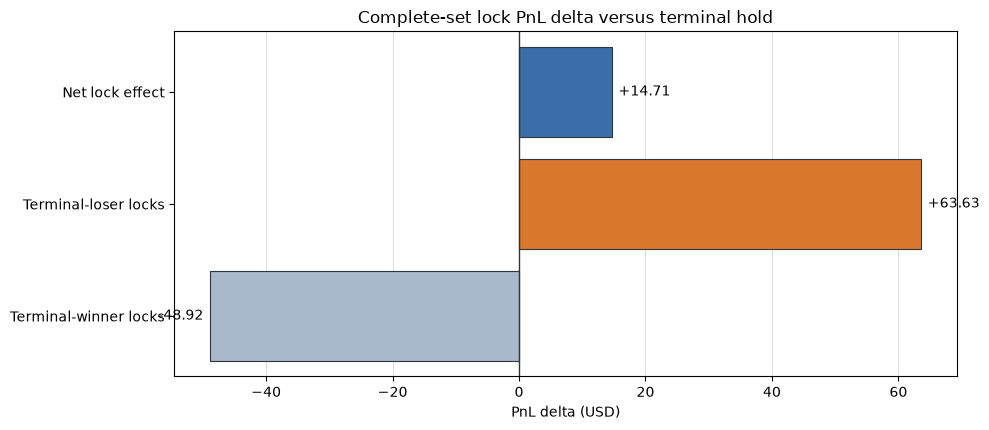

In [7]:
# Chart contract: signed component comparison; horizontal bars; exact lock-only
# terminal-hold deltas; dark/open two-tone encoding and visible zero line.
labels = ['Terminal-winner locks', 'Terminal-loser locks', 'Net lock effect']
values = [state_feedback['winner_lock_delta'], state_feedback['loser_lock_delta'], state_feedback['lock_delta']]
colors = ['#A9B8CA', '#D9772E', '#3B6EA8']
fig, ax = plt.subplots(figsize=(10, 4.4))
bars = ax.barh(labels, values, color=colors, edgecolor='#2F3640', linewidth=0.8)
ax.axvline(0, color='#333333', linewidth=1)
ax.set_title('Complete-set lock PnL delta versus terminal hold')
ax.set_xlabel('PnL delta (USD)')
ax.grid(axis='x', color='#D9DDE3', linewidth=0.7)
ax.set_axisbelow(True)
for bar, value in zip(bars, values):
    ax.text(value + (1.0 if value >= 0 else -1.0), bar.get_y()+bar.get_height()/2,
            f'{value:+.2f}', va='center', ha='left' if value >= 0 else 'right')
fig.tight_layout()
plt.show()

## Limitations and next step

- Folds 29–42 were already observed during mechanism diagnosis and cannot support promotion.
- Stateful realized-loss feedback changes later entry membership; the full-policy effect and common-entry effect are reported separately.
- Gas, merge, and redemption operating costs are excluded consistently with the baseline.
- The immediate v1 lock is not retuned. Any trailing redesign needs a new hash, preregistration, one-shot diagnostic, and two disjoint fresh blocks.